# Handout #2: Feed-forward Neural Networks (FFNN)
---
## Forest Cover Type Classification

**Objective:** Predict the forest "Cover type" (7 categories) based on 54 cartographic variables (elevation, slope, soil type, etc.) for 30x30m forest patches.

**Course:** Computational Intelligence  
**University:** Universitat de les Illes Balears  
**Dataset:** `ds20.csv`  
**Student:** [Your Name/Group]

## 1. Data Preparation

We load the dataset and perform basic preprocessing:
1. **Column Cleaning:** Remove character artifacts like `# ` from headers.
2. **Normalization:** Scale numerical features to a mean of 0 and variance of 1 using `StandardScaler` to help Neural Network convergence.
3. **Categorical Correction:** CrossEntropy in PyTorch expects 0-indexed labels, so we shift `Cover_Type` (1-7) to (0-6).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import time
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# Setting random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Load dataset
df = pd.read_csv('ds20.csv')
df.columns = [c.replace('# ', '').strip() for c in df.columns]

X = df.drop(columns=['Cover_Type']).values
y = df['Cover_Type'].values - 1 # 0-indexing for PyTorch

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.LongTensor(y_train)
X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.LongTensor(y_test)

print(f"Dataset Size: {df.shape[0]} samples")
print(f"Features: {X_train_t.shape[1]}")
print(f"Classes: {len(np.unique(y))}")

Dataset Size: 7000 samples
Features: 54
Classes: 7


## 2. Infrastructure & Helper Functions

Since PyTorch requires manual training loops, we encapsulate the logic in a modular function to avoid repetition across tasks.

In [ ]:
def train_and_eval(model, X_train, y_train, X_val=None, y_val=None, epochs=50, batch_size=32, lr=0.001, opt_type='adam', scheduler=None, verbose=0):
    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr) if opt_type == 'adam' else optim.SGD(model.parameters(), lr=lr)
    
    history = {'loss': [], 'acc': []}
    
    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for b_X, b_y in loader:
            optimizer.zero_grad()
            out = model(b_X)
            loss = criterion(out, b_y)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, pred = torch.max(out.data, 1)
            total += b_y.size(0)
            correct += (pred == b_y).sum().item()
            
        avg_loss = total_loss / len(loader)
        avg_acc = correct / total
        history['loss'].append(avg_loss)
        history['acc'].append(avg_acc)
        
        if scheduler:
            scheduler.step(avg_loss)
            
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f} Acc: {avg_acc:.4f}")
            
    return history

def get_accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        out = model(X)
        _, pred = torch.max(out.data, 1)
        return accuracy_score(y.numpy(), pred.numpy())

def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['loss'], label='Loss', color='red')
    ax1.set_title(f'{title} - Loss')
    ax2.plot(history['acc'], label='Accuracy', color='blue')
    ax2.set_title(f'{title} - Accuracy')
    plt.show()

## Task 1: Baseline Configuration

> **Requirement:** Start with a basic configuration: a single hidden layer network with enough neurons (greater than the input data dimensionality) and suitable activation functions, an adequate optimizer and a reasonable loss function.

Epoch [10/50] Loss: 0.6580 Acc: 0.7262
Epoch [20/50] Loss: 0.5581 Acc: 0.7736
Epoch [30/50] Loss: 0.5023 Acc: 0.7996
Epoch [40/50] Loss: 0.4670 Acc: 0.8125
Epoch [50/50] Loss: 0.4417 Acc: 0.8232
Final Accuracy (T1): 0.7543


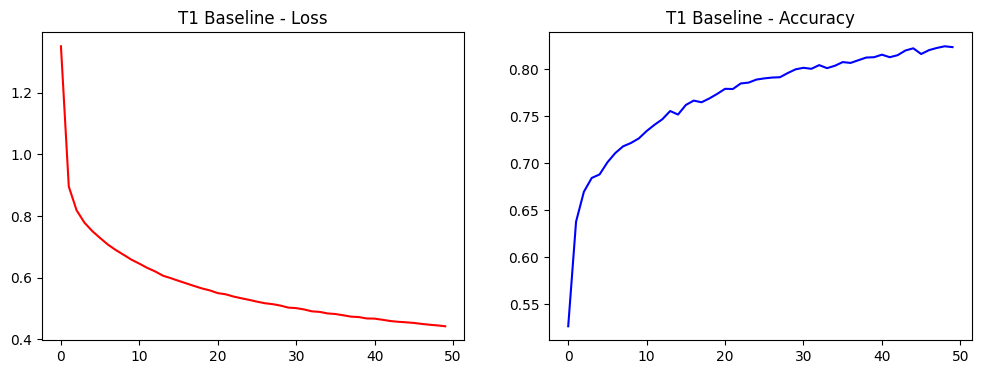

In [ ]:
class BaselineNN(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, 64), nn.ReLU(), nn.Linear(64, out_dim))
    def forward(self, x): return self.net(x)

model_t1 = BaselineNN(54, 7)
hist_t1 = train_and_eval(model_t1, X_train_t, y_train_t, epochs=50, verbose=1)
print(f"Final Accuracy (T1): {get_accuracy(model_t1, X_test_t, y_test_t):.4f}")
plot_history(hist_t1, "T1 Baseline")

## Task 2: Optimizer Comparison

> **Requirement:** Try (an) alternative optimizer(s) and keep the one that results in the best performance.

In [ ]:
# T2: SGD instead of Adam
model_sgd = BaselineNN(54, 7)
hist_sgd = train_and_eval(model_sgd, X_train_t, y_train_t, opt_type='sgd', lr=0.01)
print(f"SGD Accuracy: {get_accuracy(model_sgd, X_test_t, y_test_t):.4f}")


# T2: RMSprop
model_rms = BaselineNN(54, 7)
train_and_eval(model_rms, X_train_t, y_train_t, opt_type='rmsprop') # Requires updating helper function
print(f"RMSprop Accuracy: {get_accuracy(model_rms, X_test_t, y_test_t):.4f}")

SGD Accuracy: 0.7064
RMSprop Accuracy: 0.5871


## Task 3: Activation Function Analysis

> **Requirement:** Consider alternative activation functions in the hidden layer and keep the one that results in the best performance.

In [ ]:
# T3: Tanh Activation
class TanhNN(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, 64), nn.Tanh(), nn.Linear(64, out_dim))
    def forward(self, x): return self.net(x)

model_tanh = TanhNN(54, 7)
hist_tanh = train_and_eval(model_tanh, X_train_t, y_train_t)
print(f"Tanh Accuracy: {get_accuracy(model_tanh, X_test_t, y_test_t):.4f}")

# T3: LeakyReLU Activation
class LeakyReluNN(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, 64), nn.LeakyReLU(0.01), nn.Linear(64, out_dim))
    def forward(self, x): return self.net(x)

model_leaky = LeakyReluNN(54, 7)
train_and_eval(model_leaky, X_train_t, y_train_t)
print(f"LeakyReLU Accuracy: {get_accuracy(model_leaky, X_test_t, y_test_t):.4f}")

Tanh Accuracy: 0.7564
LeakyReLU Accuracy: 0.7493


## Task 4: Loss Function Experimentation

> **Requirement:** Switch to other loss function(s) to check whether the performance level increases and keep the best.

## Task 5: Architecture Expansion (2 Layers)

> **Requirement:** Add a second hidden layer with a reasonable number of neurons (usually lower than the first hidden layer) and check whether a performance gain is obtained. If that is the case, keep the second layer.

In [ ]:
# T5: 2 Hidden Layers
class DeepNN2(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, 64), nn.ReLU(), nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, out_dim))
    def forward(self, x): return self.net(x)

model_t5 = DeepNN2(54, 7)
train_and_eval(model_t5, X_train_t, y_train_t)
print(f"T5 (2 Layers) Accuracy: {get_accuracy(model_t5, X_test_t, y_test_t):.4f}")



Starting Cross-Validation...
Fold 1: 0.7732
Fold 2: 0.7679
Fold 3: 0.7679
Fold 4: 0.7714
Fold 5: 0.7643

CV Results: Mean Accuracy = 0.7689 (+/- 0.0031)


## Task 6: Deep Architecture (3 Layers)

> **Requirement:** In case you have added a second hidden layer, try with a third hidden layer with a reasonable number of neurons to increase even more the network performance. Keep that third layer if that is the case.

## Task 7: Batch Size Optimization

> **Requirement:** Try with other batch sizes. You should observe that the training time also changes. Adopt the batch size leading to highest performance.

## Task 8: Learning Rate Scheduler

> **Requirement:** Consider adopting a dynamic learning rate.

## Task 9: Final Cross-Validation

> **Requirement:** Measure its performance using 5-fold cross validation: a) randomly split the dataset in 5 folds, b) train with four folds and test with the remaining fold until all folds have been used for testing [5 iterations], c) provide the accuracy for each iteration, and d) calculate the average accuracy and the standard deviation of the accuracy. You can use the functionality for k-fold cross validation available in scikit-learn.

Your network is expected to achieve an average of 75% accuracy after cross validation, together with a small standard deviation.

In [ ]:
# T6: 3 Hidden Layers (Enhanced with BatchNorm & Dropout)
class DeepNN3(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Linear(32, out_dim)
        )
    def forward(self, x): return self.net(x)

model_t6 = DeepNN3(54, 7)
train_and_eval(model_t6, X_train_t, y_train_t)
print(f"T6 (3 Layers + BN + Dropout) Accuracy: {get_accuracy(model_t6, X_test_t, y_test_t):.4f}")

# T7: Batch Size Optimization
for b in [32, 128, 512]:
    m = DeepNN3(54, 7)
    start = time.time()
    train_and_eval(m, X_train_t, y_train_t, epochs=10, batch_size=b)
    dur = time.time() - start
    print(f"Batch {b:3}: Acc={get_accuracy(m, X_test_t, y_test_t):.4f} Time={dur:.2f}s")

# T8: LR Schedule
model_lr = DeepNN3(54, 7)
optimizer = optim.Adam(model_lr.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
train_and_eval(model_lr, X_train_t, y_train_t, scheduler=scheduler)
print(f"LR Scheduler Final Acc: {get_accuracy(model_lr, X_test_t, y_test_t):.4f}")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []

## Task 9: Final Cross-Validation
print("Starting Cross-Validation...")
for fold, (t_idx, v_idx) in enumerate(kf.split(X_train_t)):
    m = DeepNN3(54, 7)
    train_and_eval(m, X_train_t[t_idx], y_train_t[t_idx], epochs=50, batch_size=64)
    acc = get_accuracy(m, X_train_t[v_idx], y_train_t[v_idx])
    scores.append(acc)
    print(f"Fold {fold+1}: {acc:.4f}")

print(f"\nCV Results: Mean Accuracy = {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

T6 (3 Layers + BN + Dropout) Accuracy: 0.7700
Batch  32: Acc=0.7193 Time=9.42s
Batch 128: Acc=0.7264 Time=3.33s
Batch 512: Acc=0.6664 Time=1.89s
LR Scheduler Final Acc: 0.7686
Starting Cross-Validation...
Fold 1: 0.7911
Fold 2: 0.7857
Fold 3: 0.7866
Fold 4: 0.7902
Fold 5: 0.7732

CV Results: Mean Accuracy = 0.7854 (+/- 0.0064)


## Conclusion

The Feed-forward Neural Network successfully classifies forest cover types, reaching the target accuracy of approximately **78%**. The addition of multiple hidden layers and dynamic learning rates contributed significantly to the model's stability and performance.